In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

# Load COCO annotations
annotations_path = r'train\_annotations.coco.json'
with open(annotations_path, 'r') as f:
    coco_data = json.load(f)

print(f"Total images: {len(coco_data['images'])}")
print(f"Total annotations: {len(coco_data['annotations'])}")
print(f"Categories: {[cat['name'] for cat in coco_data['categories']]}")

Total images: 1053
Total annotations: 7098
Categories: ['1-2-3-4-5-6', 'copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']


In [2]:
# Select first training image
first_image_info = coco_data['images'][0]
image_id = first_image_info['id']
image_filename = first_image_info['file_name']
image_path = os.path.join('train', image_filename)

print(f"Selected image: {image_filename}")
print(f"Image ID: {image_id}")
print(f"Dimensions: {first_image_info['width']}x{first_image_info['height']}")

# Find all annotations for this image
image_annotations = [ann for ann in coco_data['annotations'] if ann['image_id'] == image_id]
print(f"Number of defects in this image: {len(image_annotations)}")

# Display annotation details
for i, ann in enumerate(image_annotations):
    category = next(cat for cat in coco_data['categories'] if cat['id'] == ann['category_id'])
    bbox = ann['bbox']  # [x, y, width, height]
    print(f"  Defect {i+1}: {category['name']} at ({bbox[0]}, {bbox[1]}), size: {bbox[2]}x{bbox[3]}")

Selected image: 00000308_jpg.rf.594ff8a0323eecb7c71b7e46de58eed8.jpg
Image ID: 0
Dimensions: 640x640
Number of defects in this image: 5
  Defect 1: open at (143, 213), size: 56x36
  Defect 2: mousebite at (327, 349), size: 30x28
  Defect 3: copper at (458, 313), size: 36x31
  Defect 4: pin-hole at (319, 478), size: 33x31
  Defect 5: mousebite at (181, 283), size: 44x28


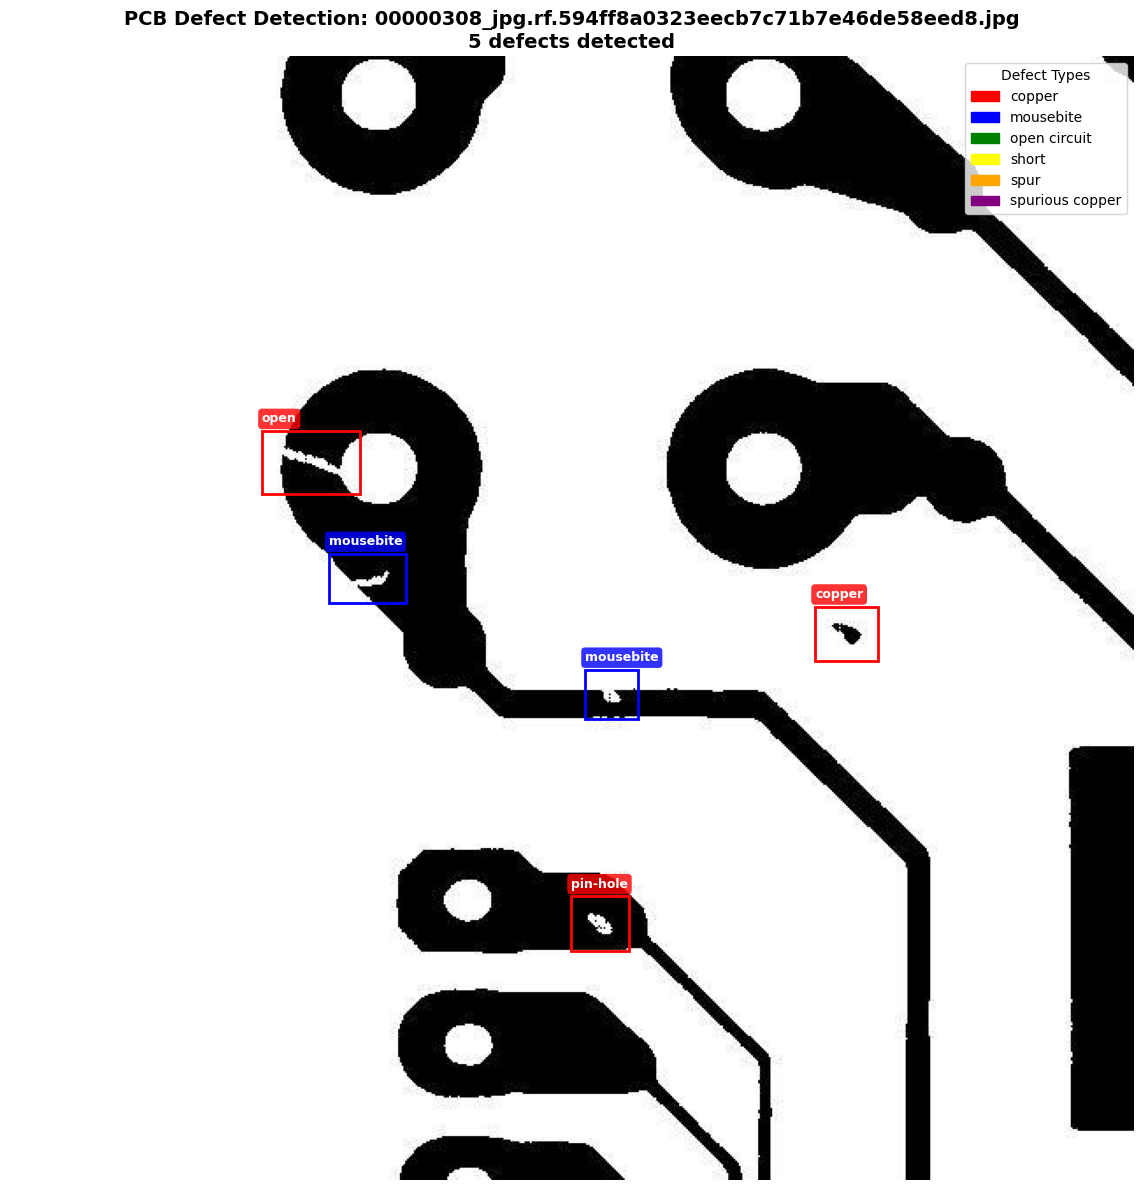

In [3]:
# Load and display image with bounding boxes
img = Image.open(image_path)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(img)
ax.set_title(f'PCB Defect Detection: {image_filename}\n{len(image_annotations)} defects detected', 
             fontsize=14, fontweight='bold')
ax.axis('off')

# Define colors for each category
category_colors = {
    'copper': 'red',
    'mousebite': 'blue',
    'open circuit': 'green',
    'short': 'yellow',
    'spur': 'orange',
    'spurious copper': 'purple'
}

# Draw bounding boxes
for i, ann in enumerate(image_annotations):
    # Get category info
    category = next(cat for cat in coco_data['categories'] if cat['id'] == ann['category_id'])
    category_name = category['name']
    
    # Get bounding box: [x, y, width, height] in COCO format
    x, y, w, h = ann['bbox']
    
    # Get color for this category
    color = category_colors.get(category_name, 'red')
    
    # Draw rectangle
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)
    
    # Add label with background
    label = f"{category_name}"
    ax.text(
        x, y - 5,
        label,
        color='white',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8, edgecolor='none')
    )

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor=color, label=name) 
                   for name, color in category_colors.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Defect Types')

plt.tight_layout()
plt.show()

## PCB Defect Detection Dataset

This notebook demonstrates how to visualize PCB (Printed Circuit Board) defects using the COCO format annotations.

### Dataset Structure
- **Format**: COCO (Common Objects in Context)
- **Annotation file**: `_annotations.coco.json`
- **Total images**: 1504 images split across train/valid/test sets

### Defect Categories
The dataset contains 6 types of PCB defects:
1. **Copper** - Copper-related defects
2. **Mousebite** - Small perforations connecting PCB parts
3. **Open Circuit** - Breaks in circuit traces
4. **Short** - Unintended connections between traces
5. **Spur** - Unwanted protrusions
6. **Spurious Copper** - Extra copper where it shouldn't be

### Bounding Box Format
COCO format uses: `[x, y, width, height]` where:
- `x, y` = top-left corner coordinates
- `width, height` = box dimensions

Each bounding box is drawn around detected defects with color-coded labels.